In [1]:
import torch
import torch.nn as nn

class CIFAR10CNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super(CIFAR10CNN, self).__init__()

        # First convolutional block
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        # Second convolutional block
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.dropout(self.relu3(self.fc1(x)))
        x = self.fc2(x)
        return x


def load_model(model_path: str, device: str = 'cuda') -> CIFAR10CNN:
    model = CIFAR10CNN(num_classes=10)

    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device)

    # Handle both direct state_dict and checkpoint dict formats
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    model = model.to(device)
    model.eval()

    return model


# CIFAR-10 class names
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Normalization parameters (computed from CIFAR-10 training set)
NORMALIZATION_MEAN = [0.4914, 0.4822, 0.4465]
NORMALIZATION_STD = [0.247, 0.2435, 0.2616]


In [3]:
import os, io, base64, requests
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

BASE_URL = os.getenv("BASE_URL", "http://154.57.164.80:30852")


def tensor_from_b64_png(b64: str) -> torch.Tensor:
    raw = base64.b64decode(b64)
    img = Image.open(io.BytesIO(raw))
    if img.size != (32, 32):
        raise ValueError("Expected 32x32 PNG")
    tensor = transforms.ToTensor()(img)  # converts to (3, 32, 32) in [0,1]
    return tensor


def b64_png_from_tensor(tensor: torch.Tensor) -> str:
    img_array = (tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    img = Image.fromarray(img_array)
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    buf.seek(0)
    return base64.b64encode(buf.getvalue()).decode("ascii")


def l2_normalized_space(a: torch.Tensor, b: torch.Tensor, mean, std) -> float:
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    a_norm = (a - mean_t) / std_t
    b_norm = (b - mean_t) / std_t
    return float(torch.norm(a_norm - b_norm))


# Download model weights
weights_path = "cifar10_model_best.pth"
if not os.path.exists(weights_path):
    print("Downloading model weights...")
    resp = requests.get(f"{BASE_URL}/model/weights")
    with open(weights_path, "wb") as f:
        f.write(resp.content)
    print(f"Saved to {weights_path}")

# Load model (assumes model.py from architecture section above)
from model import load_model, NORMALIZATION_MEAN, NORMALIZATION_STD

device = "cuda" if torch.cuda.is_available() else "cpu"
model = load_model(weights_path, device=device)
print(f"Model loaded on {device}")

# Fetch challenge
ch = requests.get(f"{BASE_URL}/challenge", timeout=10).json()
x = tensor_from_b64_png(ch["image"])  # (3, 32, 32)
orig_class = int(ch["original_class"])  # 7 (horse)
l2_threshold = float(ch["l2_threshold"])  # 3.5
mean = ch["normalization"]["mean"]
std = ch["normalization"]["std"]
mean_t = torch.tensor(mean).view(3, 1, 1)
std_t = torch.tensor(std).view(3, 1, 1)

# Verify clean prediction
x_norm = (x - mean_t) / std_t
with torch.no_grad():
    pred = model(x_norm.unsqueeze(0).to(device)).argmax(dim=1).item()
print(f"Original: class {orig_class}, Clean pred: {pred}, L2 threshold: {l2_threshold}")

Model loaded on cpu
Original: class 7, Clean pred: 7, L2 threshold: 3.5


In [4]:

def deepfool(image: torch.Tensor,
             net: nn.Module,
             num_classes: int = 10,
             overshoot: float = 0.02,
             max_iter: int = 50,
             device: str = 'cuda') -> tuple[torch.Tensor, int, int, int, torch.Tensor]:
    """
    Generate minimal adversarial perturbation using DeepFool algorithm.

    Args:
        image (torch.Tensor): Input image tensor of shape (1, C, H, W)
        net (nn.Module): Target neural network in evaluation mode
        num_classes (int): Number of top-scoring classes to consider (default: 10)
        overshoot (float): Overshoot parameter for boundary crossing (default: 0.02)
        max_iter (int): Maximum iterations before terminating (default: 50)
        device (str): Computation device ('cuda' or 'cpu')

    Returns:
        Tuple containing:
            - r_tot (torch.Tensor): Total accumulated perturbation
            - loop_i (int): Number of iterations performed
            - label (int): Original predicted class
            - k_i (int): Final adversarial class
            - pert_image (torch.Tensor): Final perturbed image
    """
    image = image.to(device)
    net = net.to(device)



    # Original prediction and class ordering (descending score)
    f_image = net(image).data.cpu().numpy().flatten()
    I = f_image.argsort()[::-1]
    label = I[0]


    # Working tensors and accumulators
    input_shape = image.shape
    pert_image = image.clone()
    r_tot = torch.zeros(input_shape).to(device)
    loop_i = 0


    # Iterate until a successful perturbation is found or the limit is reached
    while loop_i < max_iter:
        x = pert_image.clone().requires_grad_(True)
        fs = net(x)
        # Current top prediction at x
        k_i = fs.data.cpu().numpy().flatten().argsort()[::-1][0]

        # Stop when the prediction changes
        if k_i != label:
            break

        # Initialize the best candidate step for this iteration
        pert = float('inf')
        w = None

        
        # Search minimal step among candidate classes
        for k in range(1, num_classes):
            if I[k] == label:
                continue

            # Compute gradient for candidate class
            if x.grad is not None:
                x.grad.zero_()
            fs[0, I[k]].backward(retain_graph=True)
            grad_k = x.grad.data.clone()
            
            # Compute gradient for original class
            if x.grad is not None:
                x.grad.zero_()
            fs[0, label].backward(retain_graph=True)
            grad_label = x.grad.data.clone()


            # Direction and distance under linearization
            w_k = grad_k - grad_label
            f_k = (fs[0, I[k]] - fs[0, label]).data.cpu().numpy()
            pert_k = abs(f_k) / (torch.norm(w_k.flatten()) + 1e-10)


            if pert_k < pert:
                pert = pert_k
                w = w_k


        # Minimal step for the selected direction
        r_i = (pert + 1e-4) * w / (torch.norm(w.flatten()) + 1e-10)
        r_tot = r_tot + r_i

        # Apply with overshoot to ensure crossing
        pert_image = image + (1 + overshoot) * r_tot
        loop_i += 1

    return r_tot, loop_i, label, k_i, pert_image

In [5]:
# Run DeepFool in normalized space so r_tot is measured in normalized space
# pert_image comes back normalized — denormalize at the end for submission
r_tot, loop_i, label, k_i, pert_image = deepfool(
    image      = x_norm.unsqueeze(0).to(device),
    net        = model,
    num_classes= 10,
    overshoot  = 0.02,
    max_iter   = 100,
    device     = device,
)
 
print(f"DeepFool finished in {loop_i} iterations")
print(f"Original class : {label} ({CIFAR10_CLASSES[label]})")
print(f"Adversarial class: {k_i} ({CIFAR10_CLASSES[k_i]})")
 
# Denormalize pert_image back to [0,1] pixel space for submission
x_adv = (pert_image.squeeze(0).cpu() * std_t + mean_t).clamp(0, 1)
 
# Verify constraints
l2_dist = l2_normalized_space(x, x_adv, mean, std)
print(f"\nL2 (normalized space): {l2_dist:.4f}  (threshold: {l2_threshold})")
print(f"Pixel range          : [{float(x_adv.min()):.4f}, {float(x_adv.max()):.4f}]")
 
# Validate via /predict before submitting
payload = {"image": b64_png_from_tensor(x_adv)}
predict_resp = requests.post(f"{BASE_URL}/predict", json=payload, timeout=10).json()
print(f"\n/predict: {predict_resp['predicted_class_name']} (confidence: {predict_resp['confidence']:.2%})")
 
# Submit
result = requests.post(f"{BASE_URL}/submit", json=payload, timeout=10).json()
print(result)
 

DeepFool finished in 2 iterations
Original class : 7 (horse)
Adversarial class: 9 (truck)

L2 (normalized space): 0.8145  (threshold: 3.5)
Pixel range          : [0.0678, 0.9531]

/predict: truck (confidence: 33.23%)
{'flag': 'HTB{d33pf00l_k33p5_0n_f00l1ng}', 'message': 'Congratulations! Challenge solved!', 'success': True, 'validation': {'adversarial_class': 'truck', 'adversarial_prediction': 9, 'attack_direction': True, 'direction_alignment': 0.8490856289863586, 'l2_norm': 0.9642887711524963, 'l2_satisfied': True, 'l2_threshold': 3.5, 'linf_norm': 0.0156862735748291, 'misclassification': True, 'original_class': 'horse', 'original_prediction': 7, 'reasonable_linf': True, 'valid_range': True}}


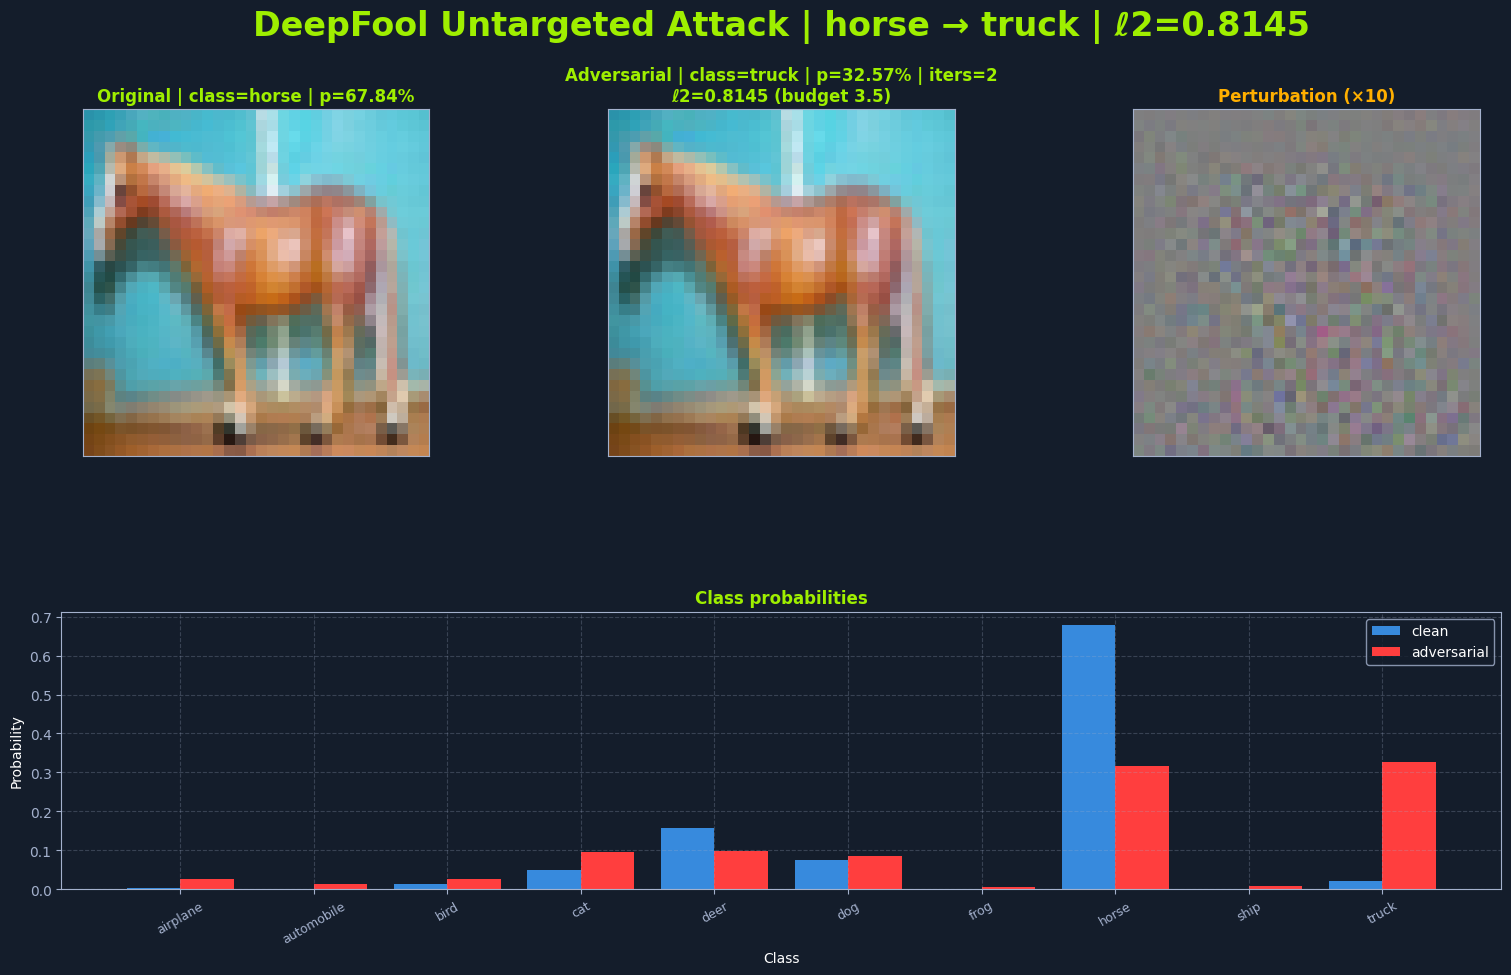

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from model import CIFAR10_CLASSES

# HTB color constants (matching htb_ai_library)
HTB_GREEN     = "#9fef00"
NODE_BLACK    = "#141d2b"
HACKER_GREY   = "#a4b1cd"
WHITE         = "#ffffff"
AZURE         = "#378add"
NUGGET_YELLOW = "#ffaf00"
MALWARE_RED   = "#ff3e3e"


def _style_axes(ax: plt.Axes) -> None:
    """Apply Hack The Box dark theme to an axes instance.

    Args:
        ax: Matplotlib axes to style
    """
    ax.set_facecolor(NODE_BLACK)
    ax.tick_params(colors=HACKER_GREY)
    for spine in ax.spines.values():
        spine.set_color(HACKER_GREY)
    ax.grid(True, color=HACKER_GREY, linestyle="--", alpha=0.25)


def visualize_deepfool_attack(model: nn.Module,
                               x_orig: torch.Tensor,
                               x_adv: torch.Tensor,
                               mean_t: torch.Tensor,
                               std_t: torch.Tensor,
                               orig_class: int,
                               adv_class: int,
                               l2_dist: float,
                               l2_threshold: float,
                               loop_i: int,
                               device: str) -> None:
    """HTB-styled visualization for CIFAR-10 DeepFool untargeted adversarial attack.

    Args:
        model        : Classifier in evaluation mode
        x_orig       : Original image tensor (3,32,32) in [0,1]
        x_adv        : Adversarial image tensor (3,32,32) in [0,1]
        mean_t       : Normalization mean tensor (3,1,1)
        std_t        : Normalization std tensor (3,1,1)
        orig_class   : Original class index
        adv_class    : Final adversarial class index
        l2_dist      : Actual ℓ2 distance in normalized space
        l2_threshold : Budget threshold
        loop_i       : Number of DeepFool iterations performed
        device       : Torch device string
    """
    model.eval()

    # Normalize for model inference
    x_orig_norm = ((x_orig - mean_t) / std_t).unsqueeze(0).to(device)
    x_adv_norm  = ((x_adv  - mean_t) / std_t).unsqueeze(0).to(device)

    # Compute probabilities from live model
    with torch.no_grad():
        clean_probs = F.softmax(model(x_orig_norm), dim=1).squeeze(0).cpu()
        adv_probs   = F.softmax(model(x_adv_norm),  dim=1).squeeze(0).cpu()
    clean_pred = int(clean_probs.argmax())
    adv_pred   = int(adv_probs.argmax())

    # Perturbation scaled for visibility
    pert_vis = ((x_adv - x_orig) * 10 + 0.5).clamp(0, 1)

    # Create figure with grid layout
    fig = plt.figure(figsize=(16, 10), facecolor=NODE_BLACK)
    gs  = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.35, height_ratios=[1, 0.8])

    # Original image panel
    ax1 = fig.add_subplot(gs[0, 0])
    _style_axes(ax1)
    ax1.imshow(x_orig.permute(1, 2, 0).numpy())
    ax1.set_title(
        f"Original | class={CIFAR10_CLASSES[clean_pred]} | p={clean_probs[clean_pred]:.2%}",
        color=HTB_GREEN, fontweight="bold"
    )
    ax1.set_xticks([])
    ax1.set_yticks([])

    # Adversarial image panel
    ax2 = fig.add_subplot(gs[0, 1])
    _style_axes(ax2)
    ax2.imshow(x_adv.permute(1, 2, 0).numpy())
    title_color = HTB_GREEN if adv_pred != orig_class else MALWARE_RED
    ax2.set_title(
        f"Adversarial | class={CIFAR10_CLASSES[adv_pred]} | p={adv_probs[adv_pred]:.2%} | iters={loop_i}\nℓ2={l2_dist:.4f} (budget {l2_threshold})",
        color=title_color, fontweight="bold"
    )
    ax2.set_xticks([])
    ax2.set_yticks([])

    # Perturbation panel (scaled for visibility)
    ax3 = fig.add_subplot(gs[0, 2])
    _style_axes(ax3)
    ax3.imshow(pert_vis.permute(1, 2, 0).numpy())
    ax3.set_title("Perturbation (×10)", color=NUGGET_YELLOW, fontweight="bold")
    ax3.set_xticks([])
    ax3.set_yticks([])

    # Class probability comparison
    ax4 = fig.add_subplot(gs[1, :])
    _style_axes(ax4)
    idx   = np.arange(len(CIFAR10_CLASSES))
    width = 0.4
    ax4.bar(idx - width/2, clean_probs.numpy(), width, color=AZURE,       label="clean")
    ax4.bar(idx + width/2, adv_probs.numpy(),   width, color=MALWARE_RED, label="adversarial")
    ax4.set_xticks(idx)
    ax4.set_xticklabels(CIFAR10_CLASSES, rotation=30, color=HACKER_GREY, fontsize=9)
    ax4.set_xlabel("Class",       color=WHITE)
    ax4.set_ylabel("Probability", color=WHITE)
    for text in ax4.get_yticklabels():
        text.set_color(HACKER_GREY)
    legend = ax4.legend(facecolor=NODE_BLACK, edgecolor=HACKER_GREY)
    for t in legend.get_texts():
        t.set_color(WHITE)
    ax4.set_title("Class probabilities", color=HTB_GREEN, fontweight="bold")

    # Add main title and display
    fig.suptitle(
        f"DeepFool Untargeted Attack | {CIFAR10_CLASSES[orig_class]} → {CIFAR10_CLASSES[adv_class]} | ℓ2={l2_dist:.4f}",
        color=HTB_GREEN, fontweight="bold", fontsize=24, y=0.98
    )
    plt.subplots_adjust(top=0.88, bottom=0.1, left=0.05, right=0.95)
    plt.show()


# Call with your existing variables
visualize_deepfool_attack(model, x, x_adv, mean_t, std_t,
                          orig_class, k_i, l2_dist, l2_threshold,
                          loop_i, device)